### homework 3 using pytorch


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print('GPU')
elif torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current Pytorch install was not build with MPS enabled.")
        device=torch.device('cpu')
        device = torch.device('mps') # for MacOS devices with MPS support
        print('MPS')
    else:
        device = torch.device('cpu')
        print('CPU')
else:
    device = torch.device('cpu')
    print('CPU')

# # --- If you want to force CPU use regardless of GPU availability, uncomment the line below
# device = torch.device('cpu')
# print('cpu')


CPU


### load and inspect MNIST dataset (training and testing)

In [ ]:
from torchvision import datasets

# initialize the MNIST training dataset
train_images = datasets.MNIST(root='data', train=True, download=True, transform=ToTensor())

# initialize the MNIST testing dataset
test_images = datasets.MNIST(root='data', train=False, download=True, transform=ToTensor())


In [ ]:
# Inspect the dimensions of train and test datasets
print('Train dataset:')
print(f'Images shape: {train_images.data.shape}')  # (60000, 28, 28)
print(f'Labels shape: {train_images.targets.shape}')  # (60000,)

print('\nTest dataset:')
print(f'Images shape: {test_images.data.shape}')  # (10000, 28, 28)
print(f'Labels shape: {test_images.targets.shape}')  # (10000,)


Train dataset:
Images shape: torch.Size([60000, 28, 28])
Labels shape: torch.Size([60000])

Test dataset:
Images shape: torch.Size([10000, 28, 28])
Labels shape: torch.Size([10000])


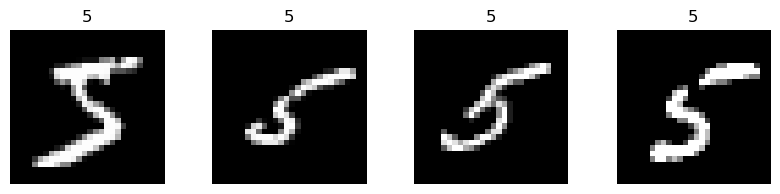

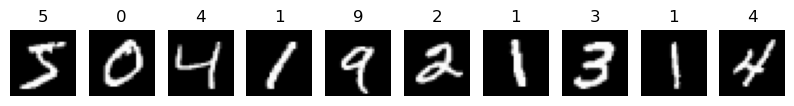

In [ ]:
# view some data images

import numpy as np
import matplotlib.pyplot as plt

def plot_sample_images(dataset, which):
    plt.figure(figsize=(10, 2))
    for i in range(len(which)):
        plt.subplot(1, len(which), i + 1)
        plt.imshow(dataset.data[which[i]], cmap='gray')
        plt.title(f"{dataset.targets[which[i]]}")
        plt.axis('off')
    plt.show()

# Plot more sample images from the training set
plot_sample_images(train_images, np.array([0, 11, 35, 47]))

plot_sample_images(train_images, np.arange(10))


In [ ]:
# build model using Sequential method

import torch.nn as nn
from collections import OrderedDict

# image shape
szx = train_images.data.shape[1]
szy = train_images.data.shape[2]
nin = szx*szy
nout = len(train_images.classes)

# number of classes
nout = len(train_images.classes)

model = nn.Sequential(
    OrderedDict([
        ('flatten', nn.Flatten()),
        ('fc1',     nn.Linear(nin, nout)),
        ('fc1 act', nn.Sigmoid())
    ])
)

print(model)

Sequential(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=10, bias=True)
  (fc1 act): Sigmoid()
)


In [ ]:
# build model by defining a class

import torch.nn as nn
import torch.nn.functional as F

szx = train_images.data.shape[1]
szy = train_images.data.shape[2]
nin = szx*szy
nout = len(train_images.classes)

class SimpleNN(nn.Module):
    def __init__(self, Nin=nin, Nout=nout):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc      = nn.Linear(Nin, Nout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

model = SimpleNN()

print(model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=784, out_features=10, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# illustrating using explicit "one hot" coding to start

from torch.nn.functional import one_hot

train_labels_onehot = one_hot(train_images.targets, num_classes=nout)
test_labels_onehot = one_hot(test_images.targets, num_classes=nout)

# print the first five training labels
print('original:\n', train_images.targets[:5])
print()
print('one hot:\n', train_labels_onehot[:5])

original:
 tensor([5, 0, 4, 1, 9])

one hot:
 tensor([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])


torch.Size([64, 1, 28, 28])
tensor([3, 1, 8, 1, 8, 3, 1, 9, 7, 2, 8, 6, 4, 2, 8, 4, 1, 8, 8, 2, 4, 8, 7, 2,
        8, 9, 4, 6, 7, 6, 6, 5, 9, 8, 5, 8, 4, 3, 5, 0, 4, 8, 2, 9, 0, 7, 6, 1,
        2, 6, 9, 3, 1, 9, 6, 8, 4, 0, 5, 1, 0, 6, 3, 5])


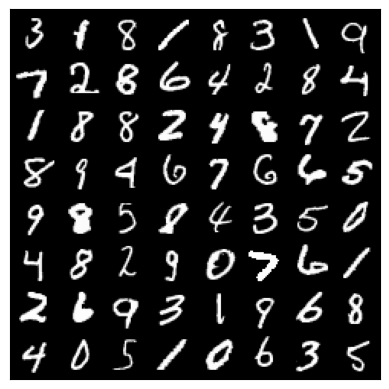

In [ ]:
# example of using DataLoader for grabbing data (images)
# this performs several operations including batching, sampling, and shuffling

from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(train_images, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_images, batch_size=batch_size, shuffle=False)

# inspect the training batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(images.shape) # shape: (sample, color_channel, image height, image width)
print(labels) # labels are not one-hot encoded.

# utils.make_grid concatenate images as a grid, and np.transpose change
# the order of dimensions (channel,h,w) -> (h,w,channel)
plt.imshow(np.transpose(torchvision.utils.make_grid(images),(1,2,0)))
plt.xticks([]); plt.yticks([])
plt.show()

In [ ]:
####################################################################

# select "optimizer" (used to train weights and biases)

import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=1e-3)

####################################################################

# select loss function (used to assess misfit during learning)

lossfn = nn.BCELoss()

####################################################################

# train model

epochs = 80

# If you are using GPU, this will move your model into GPU
model = model.to(device)

for epoch in range(epochs):

    model.train()  # Set model to training mode
    running_loss = 0.0

    # for each iteration, you will pull out a batch of images and corresponding labels from the data loader
    for images, labels in train_loader:

        # If you are using GPU, your images and labels will be moved to GPU.
        images, labels = images.to(device), labels.to(device)

        # one hot encoding
        labels = one_hot(labels,num_classes=nout).float()

        optimizer.zero_grad()   # clear gradients

        outputs = model(images) # feed the images and get outputs

        loss = lossfn(outputs, labels) # compute the loss function

        loss.backward()  # backpropagation (compute the gradients)
        optimizer.step()  # update weights based on the gradients

        running_loss += loss.item() # .item() extracts scalar value from the tensor

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {running_loss/len(train_loader)}")

Epoch 1/80, Loss: 0.5250489316515322
Epoch 2/80, Loss: 0.3885960505206956
Epoch 3/80, Loss: 0.34508027234819655
Epoch 4/80, Loss: 0.3239470939201587
Epoch 5/80, Loss: 0.3105094912908733
Epoch 6/80, Loss: 0.30037740333629315
Epoch 7/80, Loss: 0.2919568459807174
Epoch 8/80, Loss: 0.2845390871135411
Epoch 9/80, Loss: 0.27781290762714234
Epoch 10/80, Loss: 0.27161362972150227
Epoch 11/80, Loss: 0.26583088540446276
Epoch 12/80, Loss: 0.2604202764914997
Epoch 13/80, Loss: 0.25535866019250486
Epoch 14/80, Loss: 0.2505667144809959
Epoch 15/80, Loss: 0.24605278972623698
Epoch 16/80, Loss: 0.24179562060500004
Epoch 17/80, Loss: 0.23776234260627202
Epoch 18/80, Loss: 0.2339448287670038
Epoch 19/80, Loss: 0.23032781723211568
Epoch 20/80, Loss: 0.22690239130878753
Epoch 21/80, Loss: 0.22365733695182718
Epoch 22/80, Loss: 0.2205250662908371
Epoch 23/80, Loss: 0.21757833666003334
Epoch 24/80, Loss: 0.21476495480423036
Epoch 25/80, Loss: 0.21206831847871543
Epoch 26/80, Loss: 0.20951033777583128
Epoch

In [ ]:
# evaluate model performance with test dataset

model = model.to(device)
model.eval()  # Set model to evaluation mode

correct = 0; total = 0
with torch.no_grad():  # No need to calculate gradients during evaluation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Accuracy on the test set: {accuracy:.2f}%")


Accuracy on the test set: 84.90%


### Some pieces useful for completing Homework 3

In [ ]:
# how to classify all test images

test_loader_all = DataLoader(test_images, batch_size=len(test_images), shuffle=False)

dataiter = iter(test_loader_all)
images_test, labels_test = next(dataiter)

output_test = model(images_test).cpu().detach()

print(output_test.shape)
print(output_test)

torch.Size([10000, 10])
tensor([[6.4882e-02, 1.3579e-02, 5.2200e-02,  ..., 9.2449e-01, 6.7043e-02,
         2.2868e-01],
        [1.1303e-01, 4.0091e-02, 4.9577e-01,  ..., 2.4485e-03, 9.9180e-02,
         5.1643e-03],
        [4.0512e-02, 8.4400e-01, 1.5348e-01,  ..., 1.1592e-01, 1.2781e-01,
         9.0258e-02],
        ...,
        [8.4848e-04, 5.3408e-03, 4.1192e-03,  ..., 4.9558e-02, 7.5685e-02,
         1.3547e-01],
        [2.6826e-02, 6.2268e-02, 1.7021e-02,  ..., 2.8156e-02, 1.2502e-01,
         1.4106e-02],
        [1.0590e-01, 9.2030e-04, 7.5609e-02,  ..., 6.9646e-04, 3.2355e-03,
         3.8590e-03]])


Test images: torch.Size([1, 1, 28, 28])
Test labels: torch.Size([1])


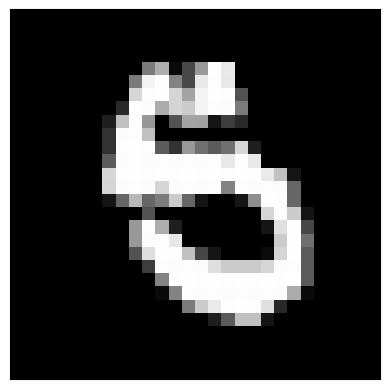

In [ ]:
# how to grab one random test image from the test database

# set batch_size = 1, you can  sample one image at a time (shuffle=True means random)
test_loader_all = DataLoader(test_images, batch_size=1, shuffle=True)

# we can pull out the next batch (all test images in this case) using the following two lines
dataiter = iter(test_loader_all)
images_test, labels_test = next(dataiter)

print(f'Test images: {images_test.shape}')
print(f'Test labels: {labels_test.shape}')

plt.imshow(np.transpose(torchvision.utils.make_grid(images_test),(1,2,0)))
plt.xticks([]); plt.yticks([])
plt.show()

tensor([[0.0649, 0.0136, 0.0522, 0.0861, 0.0703, 0.0467, 0.0133, 0.9245, 0.0670,
         0.2287]])
tensor([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])


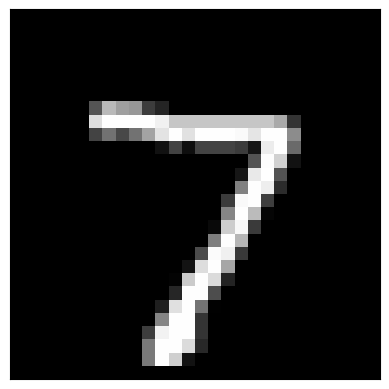

In [ ]:
# get the classification of a test image (or test images)

# move the model to the device and put into evaluation mode
model.to(device)
model.eval()

# here, we're initializing a data loader grabbing one random test image
test_loader_all = DataLoader(test_images, batch_size=1, shuffle=False)
dataiter = iter(test_loader_all)

# get one image
images_test, labels_test = next(dataiter)

out_test = model(images_test).cpu().detach()
# .cpu()     take tensors back from the GPU
# .detach()  remove gradient information

# print output layer activations
print(out_test)

# print teacher values
print(one_hot(labels_test,num_classes=nout).float())

plt.imshow(np.transpose(torchvision.utils.make_grid(images_test),(1,2,0)))
plt.xticks([]); plt.yticks([])
plt.show()

tensor([[0.1769, 0.0351, 0.1127, 0.4317, 0.0609, 0.4074, 0.0485, 0.0547, 0.2164,
         0.0289]])
tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])


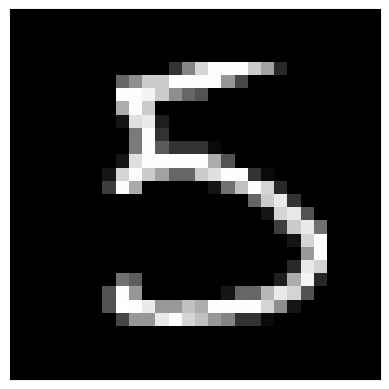

In [ ]:
# get another image (iterating over the dataloader)
images_test, labels_test = next(dataiter)

out_test = model(images_test).cpu().detach()
# .cpu()     take tensors back from the GPU
# .detach()  remove gradient information

# print output layer activations
print(out_test)

# print teacher values
print(one_hot(labels_test,num_classes=nout).float())

plt.imshow(np.transpose(torchvision.utils.make_grid(images_test),(1,2,0)))
plt.xticks([]); plt.yticks([])
plt.show()

In [ ]:
# how to extract the weight and bias from a trained model

W = model.fc.weight.data
B = model.fc.bias.data

W = W.cpu().numpy()
B = B.cpu().numpy()

print("Weights shape :", W.shape)
print("Biases shape  :", B.shape)
print()
print("Weights type :", type(W))
print("Biases type  :", type(B))
print()

# take the transpose of the weight matrix
WT = W.T
print("Weights (transpose) shape :", WT.shape)

Weights shape : (10, 784)
Biases shape  : (10,)

Weights type : <class 'numpy.ndarray'>
Biases type  : <class 'numpy.ndarray'>

Weights (transpose) shape : (784, 10)


In [ ]:
# HW Question 1

def make_decision(output_test):
    decisions_list = []

    for i in range(output_test.shape[0]):
        # Extract the activations for this image
        output_vector = output_test[i]

        # Find the index of the maximum activation - this is the predicted digit
        predicted_class = torch.argmax(output_vector).item()

        # Append to the list
        decisions_list.append(predicted_class)

    # Convert the list of decisions to a tensor of integers
    decisions_test = torch.tensor(decisions_list, dtype=torch.int)

    return decisions_test

decisions_test = make_decision(output_test)

print(decisions_test.shape)
print(decisions_test[:10])

torch.Size([10000])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9], dtype=torch.int32)


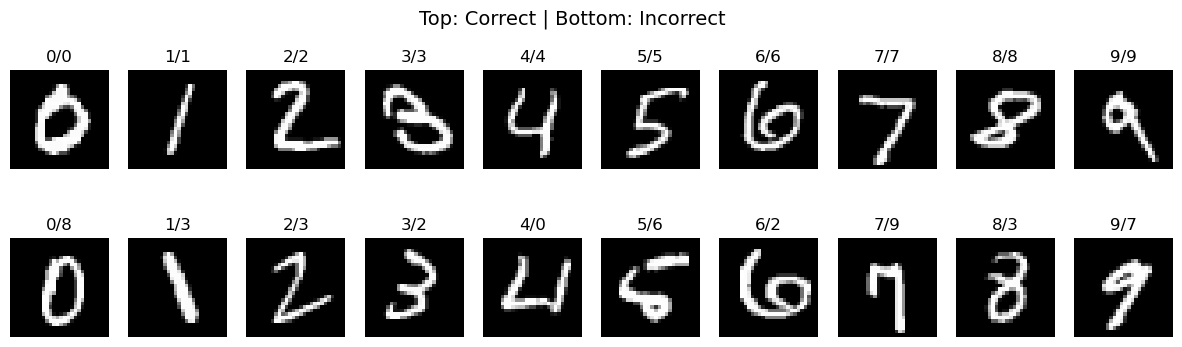

In [ ]:
# HW Question 2

def plot_correct_and_incorrect(images_test, labels_test, decisions_test):
    # Convert tensors to numpy arrays for plotting
    images_np = images_test.cpu().numpy()
    labels_np = labels_test.cpu().numpy()
    preds_np = decisions_test.cpu().numpy()

    correct_indices = {}
    incorrect_indices = {}

    # Find one correct and one incorrect classification per digit
    for i in range(len(labels_np)):
        true = labels_np[i]
        pred = preds_np[i]
        if true == pred and true not in correct_indices:
            correct_indices[true] = i
        elif true != pred and true not in incorrect_indices:
            incorrect_indices[true] = i
        if len(correct_indices) == 10 and len(incorrect_indices) == 10:
            break

    fig, axs = plt.subplots(2, 10, figsize=(15, 4))
    fig.suptitle("Top: Correct | Bottom: Incorrect", fontsize=14)

    for digit in range(10):
        # Correct (row 0)
        ax = axs[0, digit]
        if digit in correct_indices:
            idx = correct_indices[digit]
            ax.imshow(images_np[idx][0], cmap='gray')
            ax.set_title(f"{labels_np[idx]}/{preds_np[idx]}")
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=10)
        ax.axis('off')

        # Incorrect (row 1)
        ax = axs[1, digit]
        if digit in incorrect_indices:
            idx = incorrect_indices[digit]
            ax.imshow(images_np[idx][0], cmap='gray')
            ax.set_title(f"{labels_np[idx]}/{preds_np[idx]}")
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=10)
        ax.axis('off')

    axs[0, 0].set_ylabel("Correct", fontsize=12)
    axs[1, 0].set_ylabel("Incorrect", fontsize=12)

    plt.show()

plot_correct_and_incorrect(images_test, labels_test, decisions_test)

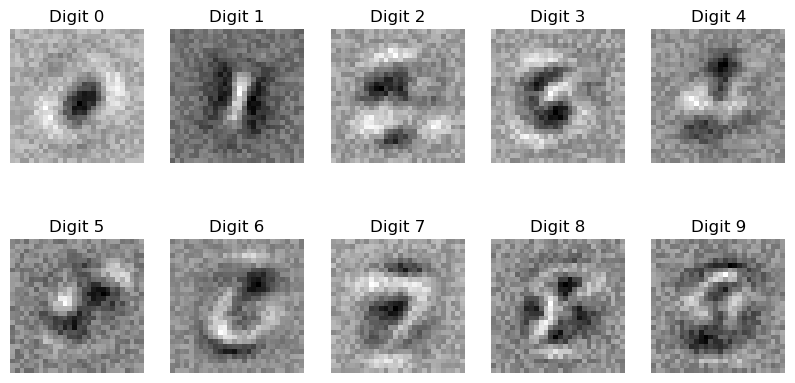

In [ ]:
# HW Question 3

weights = W

# Create a figure
plt.figure(figsize=(10, 5))  # Adjust size as needed

for i in range(10):
    weight_image = weights[i].reshape(28, 28)  # Reshape to 28x28

    plt.subplot(2, 5, i + 1)
    plt.imshow(weight_image, cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')

plt.show()

In [ ]:
# HW Question 4

X_test = images_test.cpu().numpy().reshape(-1, 28*28) / 255.0

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

z = np.dot(X_test, W.T) + B  # Shape: (10000, 10)
outputs_np = sigmoid(z)

model.eval()
with torch.no_grad():
    images_test = images_test.to(device).float() / 255.0
    outputs_torch = model(images_test).cpu().numpy()

difference = np.abs(outputs_np - outputs_torch)
epsilon = 1e-4
print("Outputs match within tolerance:", np.all(difference < epsilon))
print("Max difference:", np.max(difference))

Outputs match within tolerance: True
Max difference: 5.9604645e-08
